# SHAP extraction results — ours vs Autolycus base-SHAP

For each `(dataset, target model)` we compare our SHAP attack against the Autolycus SHAP baseline
via `run_attack_auto_compare(et=1)`, which runs both on the **same** sample sets and reports
prediction agreement (Eq. fidelity).

**Method.** Ours = `traverse_explanations_SHAP3` (Phase 1 `create_manifold_aware_diverse_samples_corrected`
+ Phase 2 `generate_shap_informed_samples_new` + Phase 3 SHAP-guided ε-traversal). Baseline =
`traverse_explanations_SHAP` (Autolycus). `main_variant='best'` optionally swaps DT/RF to the
SHAP4b boundary-densification variant.

> **Note (from project notes):** SHAP3 is the robust win on **non-tree** targets (LR/NB/KNN).
> SHAP4b's tree gains did **not** replicate under mean-aggregation (only adult+RF survived the
> max-over-refits fix), so `shap3` is the headline; `best` is a tree ablation only.

**Protocol.** Paired sample sets (compare function runs ours & base on the same sets); surrogate
refits aggregated by **MEAN** (no max/argmax leak); **one** budget per call so `argmaxing` is a
no-op; per-set paired similarities → mean ± std + paired Wilcoxon; fixed `seed`. **Parameters
align with Autolycus SHAP: n=5 seeds/class, k=3 top features.** Budgets are per dataset
(breast $Q{\le}100$; others $Q{\le}1000$); x-axis is the query budget (Autolycus convention).

Self-contained: the only project import is `run_attack_auto_compare` from `attack_utils`.

## 0. Engine

Identical logic to `shap_paper_run.py` (the parallel CLI); inlined so the notebook stands alone.
`run_dataset` sweeps one dataset's models over the budget list and saves JSON incrementally.

In [ ]:
import os, json, time, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from attack_utils import run_attack_auto_compare   # the attack (unchanged)

DATASETS = {0: 'iris', 1: 'crop', 2: 'adult', 3: 'breast', 4: 'nursery', 5: 'mushroom'}
MODELS   = {0: 'DT', 1: 'LR', 2: 'NB', 3: 'KNN', 4: 'RF', 5: 'P'}
DEFAULT_MODELS = [1, 2, 3, 0, 4]     # LR, NB, KNN, DT, RF
MODEL_DISP = {'LR': 'LR', 'NB': 'NB', 'KNN': 'KNN', 'DT': 'DT', 'RF': 'RF'}


def _per_set(rtest):
    '''Flatten the compare function's nested [batch][set] list -> per-set MEAN similarities.'''
    return [float(s) for batch in (rtest or []) for s in batch]


def run_dataset(ds, models=DEFAULT_MODELS, q_list=(100, 250, 500, 1000), hms=10, seed=0,
                nfe=3, size=5, main_variant='shap3', out_dir='paper_results'):
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f'shap_sweep_n{size}_k{nfe}_ds{ds}.json')
    q_list = list(q_list)
    rows = []
    for m in models:
        mname = MODELS.get(m, str(m)); t0 = time.time()
        try:
            main_all = {Q: [] for Q in q_list}; base_all = {Q: [] for Q in q_list}
            for Q in q_list:
                out = run_attack_auto_compare(ds, m, 1, hms, [size], [nfe], [Q], False,
                                              seed=seed, main_variant=main_variant)
                main_all[Q] = _per_set(out[1]); base_all[Q] = _per_set(out[3])

            def _pack(d):
                return {'fid_mean': [round(float(np.mean(d[Q])), 4) for Q in q_list],
                        'fid_std':  [round(float(np.std(d[Q])), 4) for Q in q_list],
                        'fid_all':  [[round(x, 4) for x in d[Q]] for Q in q_list]}

            row = {'dataset': DATASETS[ds], 'model': mname, 'ds': ds, 'm': m, 'q_cap': q_list,
                   'hms': hms, 'size': size, 'nfe': nfe, 'seed': seed, 'main_variant': main_variant,
                   'main': _pack(main_all), 'base': _pack(base_all), 'secs': round(time.time() - t0, 1)}
            L = np.array(main_all[q_list[-1]], float); B = np.array(base_all[q_list[-1]], float)
            n = min(len(L), len(B)); L, B = L[:n], B[:n]
            row['delta_top'] = round(float(L.mean() - B.mean()), 4) if n else None
            row['wilcoxon_p_top'] = (float(wilcoxon(L, B).pvalue) if (n and not np.allclose(L, B)) else 1.0)
        except Exception as e:
            traceback.print_exc()
            row = {'dataset': DATASETS[ds], 'model': mname, 'ds': ds, 'm': m,
                   'error': repr(e), 'secs': round(time.time() - t0, 1)}
        rows.append(row)
        print('ROWDONE', row['dataset'], row['model'], 'delta_top', row.get('delta_top'),
              'secs', row['secs'], flush=True)
        with open(path, 'w') as f:
            json.dump(rows, f, indent=2)
    return rows

## 1. Config

Budgets are per dataset (breast small). SHAP convention n=5/k=3. `MAIN='shap3'` is the headline;
switch to `'best'` to route DT/RF through SHAP4b as a tree ablation.

In [2]:
from pathlib import Path
SIZE, NFE, HMS, SEED = 5, 3, 10, 0
MAIN = 'shap3'                       # 'shap3' (headline) or 'best' (SHAP4b trees)
Q_BY_DS = {0: [25, 50, 100],            # iris  -- small, low budget (like breast)
           1: [100, 250, 500, 1000],    # crop
           2: [100, 250, 500, 1000],    # adult
           3: [25, 50, 100],            # breast -- small, low budget
           4: [100, 250, 500, 1000],    # nursery
           5: [100, 250, 500, 1000]}    # mushroom
RESULT_DIR = Path('paper_results')
FIG_DIR    = Path(f'paper_results/shap_sweep_n{SIZE}_k{NFE}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

HEADLINE = ['LR', 'NB', 'KNN']       # non-tree, the robust SHAP3 regime
APPENDIX = ['DT', 'RF']              # trees
DATASET_ORDER = ['crop', 'adult', 'breast', 'nursery', 'mushroom']

## 2. Load results (or run any missing datasets)

Set `run_missing=True` to compute a dataset whose JSON is absent. **SHAP is slow** (Kernel
explainer); run in parallel with `shap_paper_run.py` per dataset for the full grid.

In [3]:
def load_or_run(size=SIZE, nfe=NFE, datasets=(1, 2, 3, 4, 5), models=DEFAULT_MODELS,
                hms=HMS, seed=SEED, main_variant=MAIN, run_missing=False):
    rows = []
    for ds in datasets:
        p = RESULT_DIR / f'shap_sweep_n{size}_k{nfe}_ds{ds}.json'
        if p.exists():
            rows += json.loads(p.read_text())
        elif run_missing:
            print('running', DATASETS[ds], '...')
            rows += run_dataset(ds, models=list(models), q_list=Q_BY_DS[ds], hms=hms, seed=seed,
                                nfe=nfe, size=size, main_variant=main_variant, out_dir=str(RESULT_DIR))
        else:
            print('MISSING (skipped):', p.name)
    return rows

sweep = load_or_run()
errs = [(r['dataset'], r['model']) for r in sweep if 'error' in r]
if errs:
    print('cells with errors:', errs)
sweep = [r for r in sweep if 'error' not in r]

recs = []
for r in sweep:
    disp = MODEL_DISP.get(r['model'], r['model'])
    for qi, qc in enumerate(r['q_cap']):
        recs.append({'dataset': r['dataset'], 'model': disp, 'arm': 'ours', 'q_cap': qc,
                     'fid': r['main']['fid_mean'][qi], 'fid_std': r['main']['fid_std'][qi]})
        recs.append({'dataset': r['dataset'], 'model': disp, 'arm': 'base', 'q_cap': qc,
                     'fid': r['base']['fid_mean'][qi], 'fid_std': r['base']['fid_std'][qi]})
tidy = pd.DataFrame(recs)
META = {(MODEL_DISP.get(r['model'], r['model']), r['dataset']):
        r.get('wilcoxon_p_top') for r in sweep}
if len(tidy):
    tidy.to_csv(RESULT_DIR / f'shap_sweep_n{SIZE}_k{NFE}.csv', index=False)
    print(len(sweep), 'cells;  raw plot data ->', RESULT_DIR / f'shap_sweep_n{SIZE}_k{NFE}.csv')
tidy.head()

25 cells;  raw plot data -> paper_results/shap_sweep_n5_k3.csv


,dataset,model,arm,q_cap,fid,fid_std
0,crop,LR,ours,100,0.7063,0.0388
1,crop,LR,base,100,0.7486,0.0355
2,crop,LR,ours,250,0.7635,0.0337
3,crop,LR,base,250,0.7482,0.0322
4,crop,LR,ours,500,0.8121,0.0245


## 3. Table — ours vs Autolycus-SHAP (top budget)

In [4]:
def star(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ''
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

# each cell at its own top budget (breast=100, others=1000)
tidy['_is_top'] = tidy.groupby(['model', 'dataset'])['q_cap'].transform('max') == tidy['q_cap']
top = tidy[tidy['_is_top']].copy()

def show(models, title):
    print(f"\n=== {title}  (each cell at its top budget, n={SIZE}, k={NFE}, {HMS} sets, main={MAIN}) ===")
    recs = []
    for mdl in models:
        for ds in DATASET_ORDER:
            sub = top[(top.model == mdl) & (top.dataset == ds)]
            if sub.empty:
                continue
            o = sub[sub.arm == 'ours'].fid.iloc[0]; b = sub[sub.arm == 'base'].fid.iloc[0]
            p = META.get((mdl, ds))
            recs.append({'model': mdl, 'dataset': ds, 'ours': f"{o:.3f}", 'Autolycus': f"{b:.3f}",
                         'delta': f"{100*(o-b):+.1f}{star(p)}"})
    print(pd.DataFrame(recs).set_index(['model', 'dataset']).to_string())

show(HEADLINE, 'HEADLINE: non-tree targets (SHAP3 regime)')
show(APPENDIX, 'APPENDIX: tree targets')

d = top[top.arm == 'ours'].set_index(['model', 'dataset']).fid - \
    top[top.arm == 'base'].set_index(['model', 'dataset']).fid
print(f"\nours > Autolycus in {(d > 0).sum()}/{len(d)} cells; mean delta {100*d.mean():+.2f} pp.")


=== HEADLINE: non-tree targets (SHAP3 regime)  (each cell at its top budget, n=5, k=3, 10 sets, main=shap3) ===
                 ours Autolycus    delta
model dataset                           
LR    crop      0.860     0.813    +4.6*
      adult     0.848     0.850     -0.2
      breast    0.907     0.942    -3.5*
      nursery   0.914     0.787  +12.7**
      mushroom  0.808     0.696  +11.3**
NB    crop      0.638     0.633     +0.5
      adult     0.952     0.891    +6.1*
      breast    0.916     0.886     +3.1
      nursery   0.639     0.524  +11.4**
      mushroom  0.877     0.887     -1.0
KNN   crop      0.706     0.711     -0.5
      adult     0.868     0.849    +1.9*
      breast    0.945     0.908     +3.6
      nursery   0.590     0.555   +3.5**
      mushroom  0.824     0.785    +3.9*

=== APPENDIX: tree targets  (each cell at its top budget, n=5, k=3, 10 sets, main=shap3) ===
                 ours Autolycus delta
model dataset                        
DT    crop      0.94

## 4. Query-budget curves — one panel per (dataset, model)

Ours vs Autolycus-SHAP vs query budget. Saved to `paper_results/shap_sweep_n{SIZE}_k{NFE}/`.

saved 25 curves to paper_results/shap_sweep_n5_k3


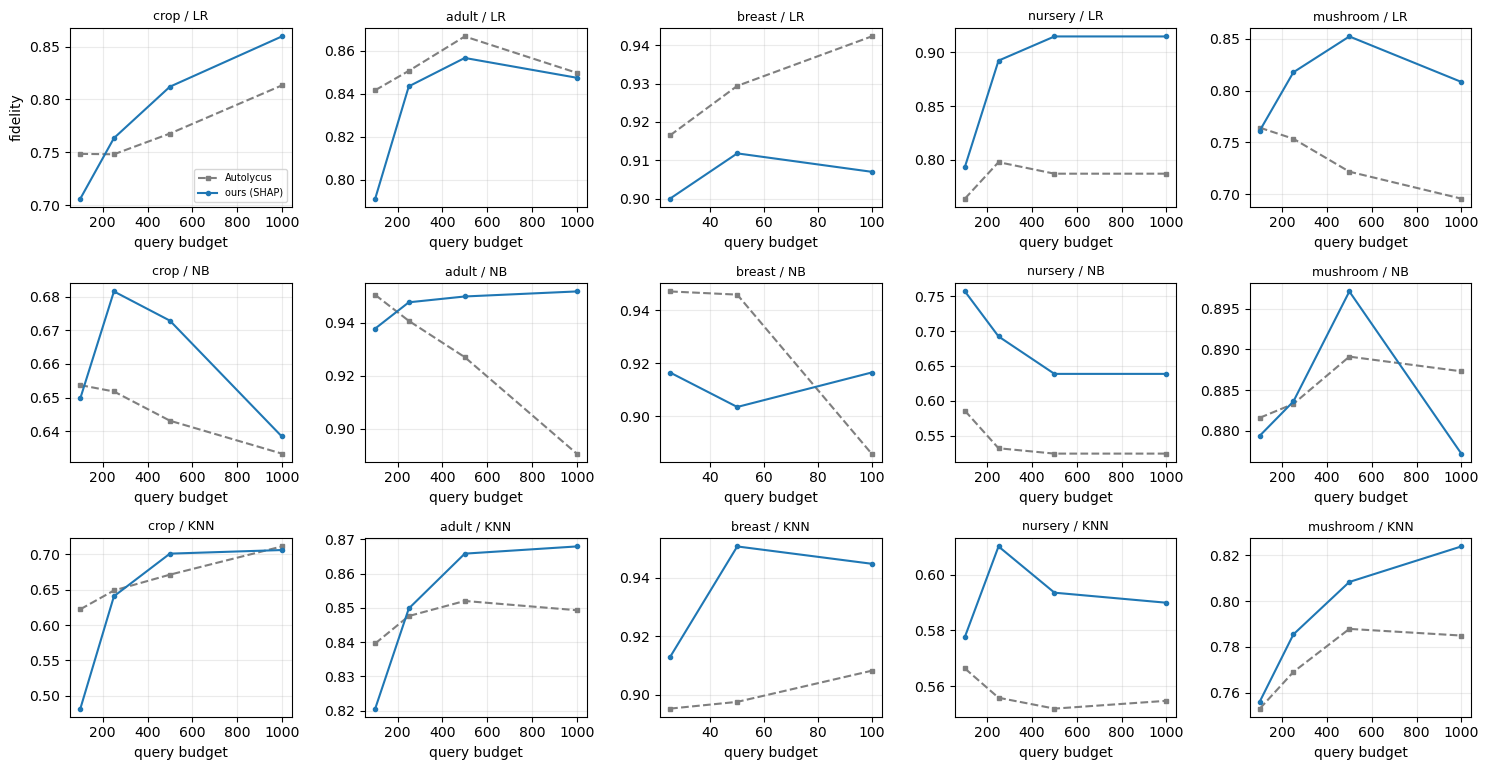

In [5]:
def plot_cell(r, ax=None):
    disp = MODEL_DISP.get(r['model'], r['model'])
    own = ax is not None
    if not own:
        fig, ax = plt.subplots(figsize=(4.2, 3.2))
    xb = np.array(r['q_cap'], float)   # query budget (Autolycus convention)
    ax.plot(xb, r['base']['fid_mean'], '--', color='tab:gray', marker='s', ms=3, label='Autolycus')
    ax.plot(xb, r['main']['fid_mean'], '-', color='tab:blue', marker='o', ms=3, label='ours (SHAP)')
    ax.set_title(f"{r['dataset']} / {disp}", fontsize=9)
    ax.set_xlabel('query budget'); ax.set_ylabel('fidelity'); ax.grid(alpha=0.25); ax.set_ylim(0.4, 1.0)
    if not own:
        ax.legend(fontsize=7); plt.tight_layout()
        fig.savefig(FIG_DIR / f"{r['dataset']}_{disp}.png", dpi=140); plt.close(fig)

for r in sweep:
    plot_cell(r)
print('saved', len(sweep), 'curves to', FIG_DIR)

hd = {(MODEL_DISP.get(r['model'], r['model']), r['dataset']): r for r in sweep}
ncol = len(DATASET_ORDER); nrow = len(HEADLINE)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.6 * nrow), squeeze=False)
for i, mdl in enumerate(HEADLINE):
    for j, ds in enumerate(DATASET_ORDER):
        ax = axes[i][j]; r = hd.get((mdl, ds))
        if r:
            plot_cell(r, ax=ax)
        else:
            ax.axis('off')
        if not (i == 0 and j == 0):
            ax.set_ylabel('')
if sweep:
    axes[0][0].legend(fontsize=7, loc='lower right')
plt.tight_layout(); fig.savefig(FIG_DIR / 'grid_headline.png', dpi=140); plt.show()

## 5. Paper figure — ours vs Autolycus (standard-error band)

Two lines per panel: **ours (SHAP3)** and **Autolycus-SHAP**, each with a **standard-error band**
(std/√10) over the seed sets. Saved to `clean_grid.png`.

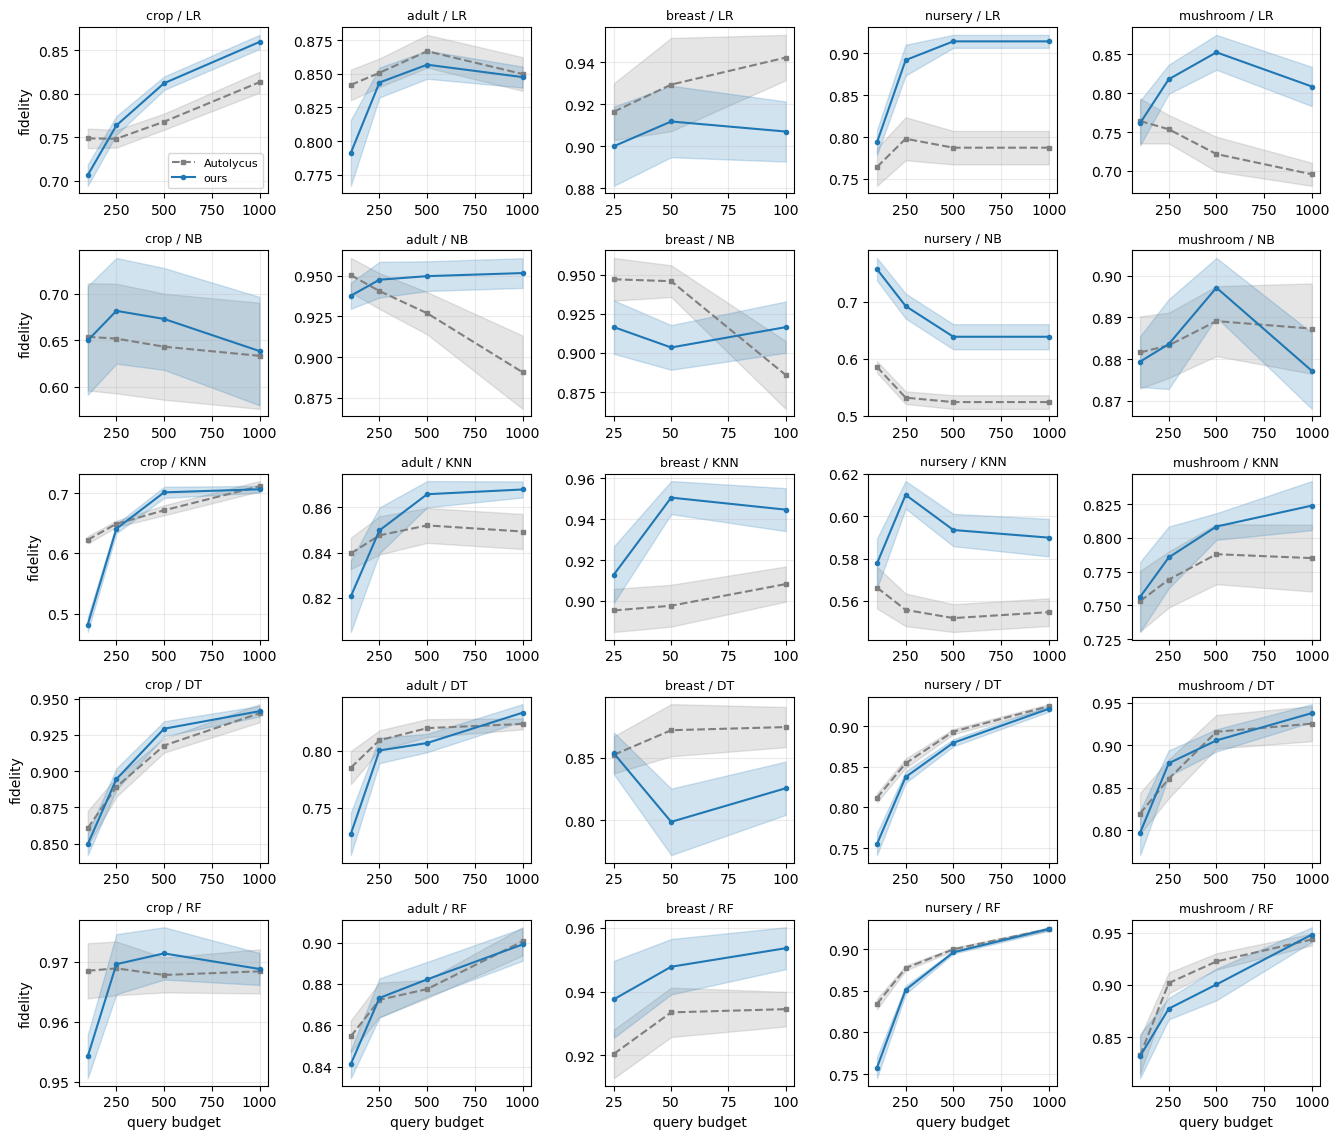

In [6]:
def _se(all_by_q):
    return np.array([np.std(v) / np.sqrt(len(v)) if len(v) else 0.0 for v in all_by_q])

def plot_clean(r, ax):
    xb = np.array(r['q_cap'], float)
    o = r['main']; om = np.array(o['fid_mean']); o_se = _se(o['fid_all'])
    b = r['base']; bm = np.array(b['fid_mean']); b_se = _se(b['fid_all'])
    ax.plot(xb, bm, '--', color='tab:gray', marker='s', ms=3, label='Autolycus')
    ax.fill_between(xb, bm - b_se, bm + b_se, color='tab:gray', alpha=0.2)
    ax.plot(xb, om, '-', color='tab:blue', marker='o', ms=3, label='ours')
    ax.fill_between(xb, om - o_se, om + o_se, color='tab:blue', alpha=0.2)
    disp = MODEL_DISP.get(r['model'], r['model'])
    ax.set_title(f"{r['dataset']} / {disp}", fontsize=9)
    ax.set_xlabel('query budget'); ax.set_ylabel('fidelity'); ax.grid(alpha=0.25); ax.set_ylim(0.4, 1.0)

MODELS_ALL = HEADLINE + APPENDIX
cells_by = {(MODEL_DISP.get(r['model'], r['model']), r['dataset']): r for r in sweep}
fig, axes = plt.subplots(len(MODELS_ALL), len(DATASET_ORDER),
                         figsize=(2.7 * len(DATASET_ORDER), 2.3 * len(MODELS_ALL)), squeeze=False)
for i, mdl in enumerate(MODELS_ALL):
    for j, ds in enumerate(DATASET_ORDER):
        ax = axes[i][j]; r = cells_by.get((mdl, ds))
        if r:
            plot_clean(r, ax)
        else:
            ax.axis('off')
        if j != 0:
            ax.set_ylabel('')
        if i != len(MODELS_ALL) - 1:
            ax.set_xlabel('')
if sweep:
    axes[0][0].legend(fontsize=8, loc='lower right')
plt.tight_layout()
fig.savefig(FIG_DIR / 'clean_grid.png', dpi=150)
plt.show()